Processing image_9.jpg...


libpng warning: iCCP: known incorrect sRGB profile


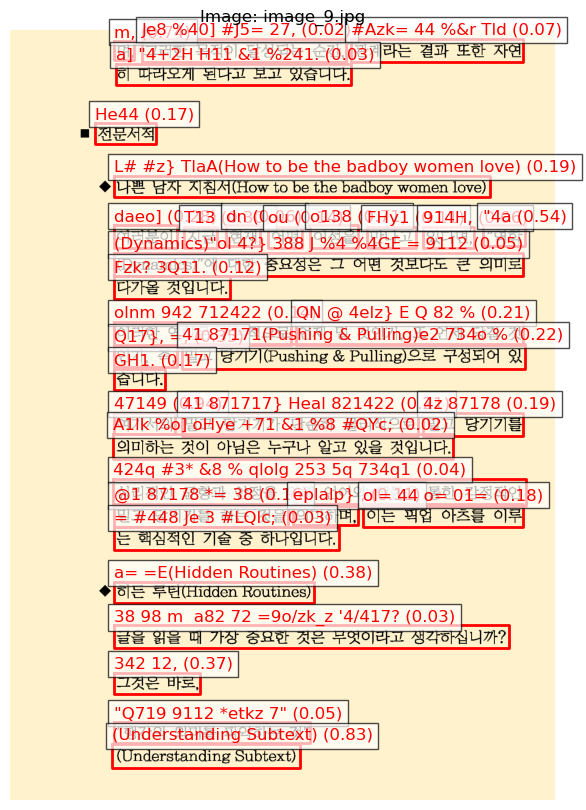

Text detected in image_9.jpg:
Text: m,, Confidence: 0.74
Bounding Box: [[237, 25], [283, 25], [283, 67], [237, 67]]
Text: Je8 %40] #J5= 27,, Confidence: 0.02
Bounding Box: [[300, 20], [764, 20], [764, 72], [300, 72]]
Text: #Azk= 44 %&r Tld, Confidence: 0.07
Bounding Box: [[776, 20], [1168, 20], [1168, 72], [776, 72]]
Text: a] "4+2H H11 &1 %241., Confidence: 0.03
Bounding Box: [[240, 76], [776, 76], [776, 124], [240, 124]]
Text: He44, Confidence: 0.17
Bounding Box: [[192, 212], [332, 212], [332, 260], [192, 260]]
Text: L# #z} TlaA(How to be the badboy women love), Confidence: 0.19
Bounding Box: [[236, 332], [1092, 332], [1092, 380], [236, 380]]
Text: daeo], Confidence: 0.28
Bounding Box: [[236, 444], [380, 444], [380, 496], [236, 496]]
Text: T13, Confidence: 0.30
Bounding Box: [[396, 448], [472, 448], [472, 496], [396, 496]]
Text: dn, Confidence: 0.06
Bounding Box: [[492, 444], [568, 444], [568, 492], [492, 492]]
Text: ou, Confidence: 0.14
Bounding Box: [[588, 448], [664, 448], [664, 49

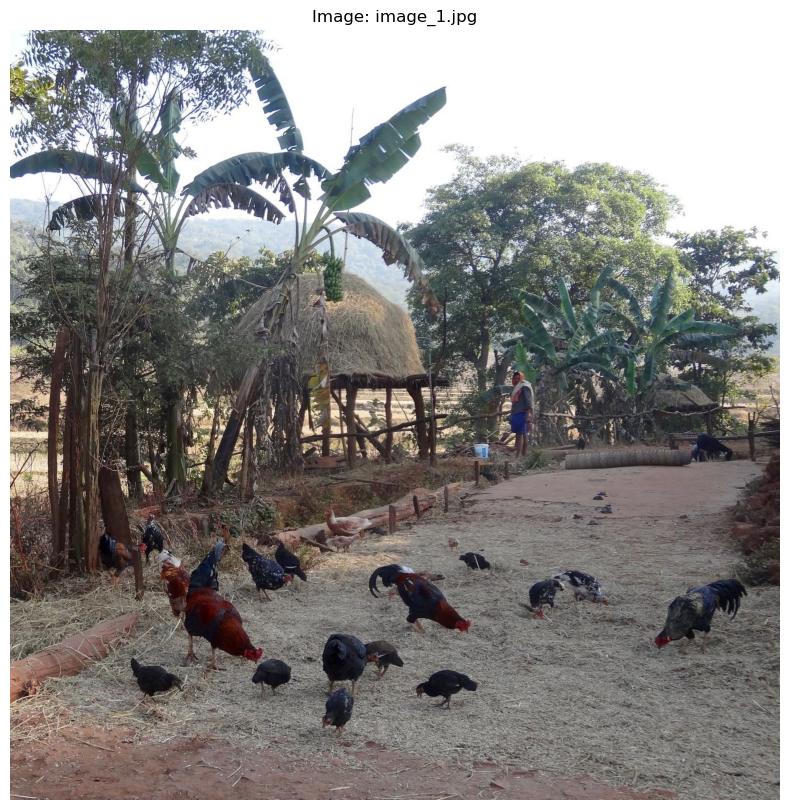

Text detected in image_1.jpg:
No text detected
--------------------------------------------------
Processing image_4.jpg...


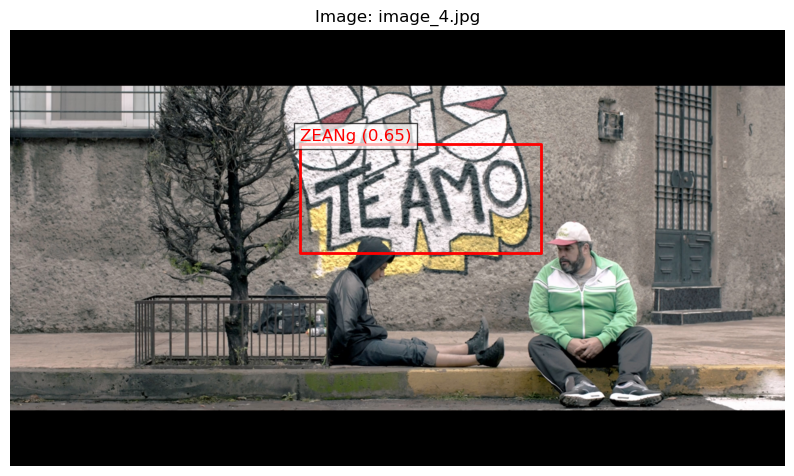

Text detected in image_4.jpg:
Text: ZEANg, Confidence: 0.65
Bounding Box: [[717, 283], [1315, 283], [1315, 553], [717, 553]]
--------------------------------------------------
Processing image_5.jpg...


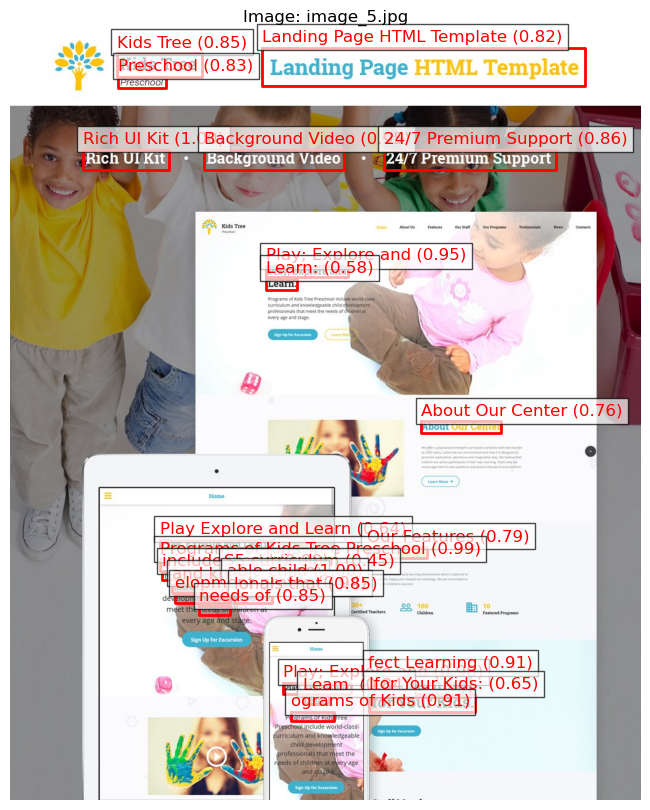

Text detected in image_5.jpg:
Text: Kids Tree, Confidence: 0.85
Bounding Box: [[173, 37], [311, 37], [311, 75], [173, 75]]
Text: Landing Page HTML Template, Confidence: 0.82
Bounding Box: [[409, 28], [933, 28], [933, 90], [409, 90]]
Text: Preschool, Confidence: 0.83
Bounding Box: [[175, 75], [253, 75], [253, 93], [175, 93]]
Text: Rich UI Kit, Confidence: 1.00
Bounding Box: [[118, 194], [258, 194], [258, 226], [118, 226]]
Text: Background Video, Confidence: 0.95
Bounding Box: [[314, 194], [542, 194], [542, 226], [314, 226]]
Text: 24/7 Premium Support, Confidence: 0.86
Bounding Box: [[606, 194], [886, 194], [886, 226], [606, 226]]
Text: Play; Explore and, Confidence: 0.95
Bounding Box: [[415, 383], [549, 383], [549, 401], [415, 401]]
Text: Learn:, Confidence: 0.58
Bounding Box: [[415, 403], [465, 403], [465, 421], [415, 421]]
Text: About Our Center, Confidence: 0.76
Bounding Box: [[667, 635], [797, 635], [797, 653], [667, 653]]
Text: Play Explore and Learn, Confidence: 0.64
Bounding Box:

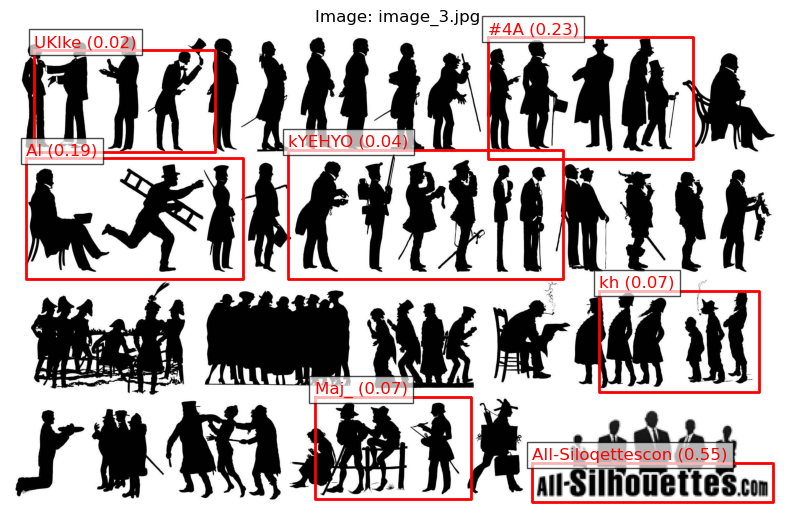

Text detected in image_3.jpg:
Text: UKIke, Confidence: 0.02
Bounding Box: [[74, 62], [634, 62], [634, 378], [74, 378]]
Text: #4A, Confidence: 0.23
Bounding Box: [[1476, 21], [2110, 21], [2110, 398], [1476, 398]]
Text: Al, Confidence: 0.19
Bounding Box: [[49, 397], [719, 397], [719, 771], [49, 771]]
Text: kYEHYO, Confidence: 0.04
Bounding Box: [[860, 370], [1708, 370], [1708, 769], [860, 769]]
Text: kh, Confidence: 0.07
Bounding Box: [[1822, 806], [2314, 806], [2314, 1118], [1822, 1118]]
Text: Maj_, Confidence: 0.07
Bounding Box: [[942, 1134], [1426, 1134], [1426, 1450], [942, 1450]]
Text: AII-Siloqettescon, Confidence: 0.55
Bounding Box: [[1614, 1338], [2358, 1338], [2358, 1458], [1614, 1458]]
--------------------------------------------------
Processing image_6.jpg...


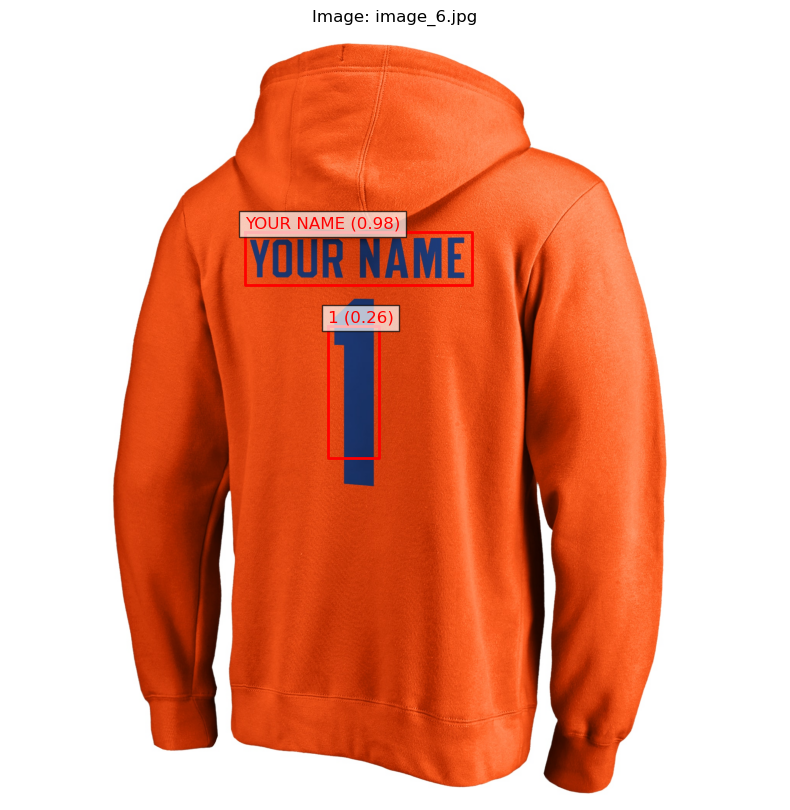

Text detected in image_6.jpg:
Text: YOUR NAME, Confidence: 0.98
Bounding Box: [[609, 525], [1199, 525], [1199, 663], [609, 663]]
Text: 1, Confidence: 0.26
Bounding Box: [[825, 769], [959, 769], [959, 1111], [825, 1111]]
--------------------------------------------------
Processing image_10.jpg...


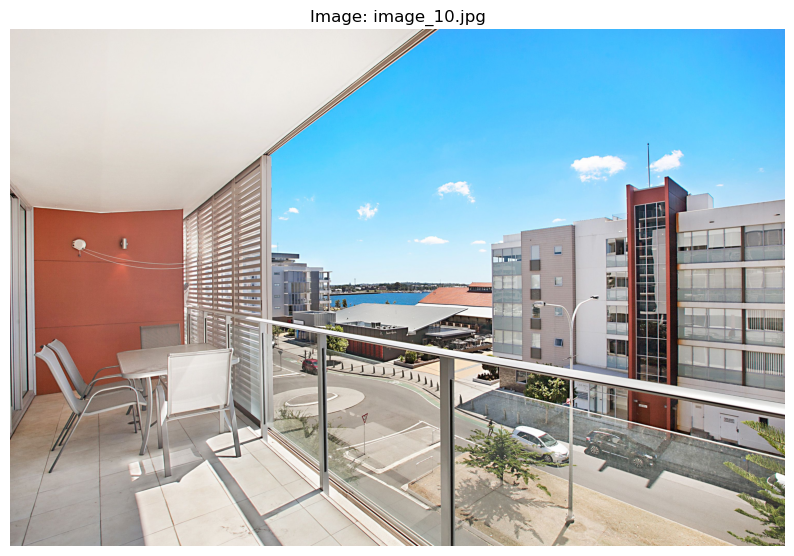

Text detected in image_10.jpg:
No text detected
--------------------------------------------------
Processing complete!


In [29]:
import os
import easyocr
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Initialize the OCR reader
# en for English - you can add more languages as needed
reader = easyocr.Reader(['en'])

# Path to data directory
data_dir = 'data'

# Get all jpg files
jpg_files = [f for f in os.listdir(data_dir) if f.endswith('.jpg')]

# Process each jpg file
results = {}
for jpg_file in jpg_files:
    # Full path to the image
    img_path = os.path.join(data_dir, jpg_file)
    
    # Read the image
    print(f"Processing {jpg_file}...")
    
    # Use easyOCR to detect text
    text_results = reader.readtext(
        img_path,
        decoder = 'greedy',  # 'greedy', 'beamsearch' and 'wordbeamsearch'.
        mag_ratio=0.5,
        batch_size = 1,
        # paragraph = True
        )
    
    # Store results
    results[jpg_file] = text_results
    
    # Display the image and detected text
    img = Image.open(img_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(np.array(img))
    
    # Draw bounding boxes for each detected text
    if text_results:
        for detection in text_results:
            bbox, text, score = detection
            # Convert bbox coordinates to numpy array
            bbox = np.array(bbox)
            
            # Draw rectangle
            plt.plot([bbox[0][0], bbox[1][0], bbox[2][0], bbox[3][0], bbox[0][0]], 
                    [bbox[0][1], bbox[1][1], bbox[2][1], bbox[3][1], bbox[0][1]], 
                    'r-', linewidth=2)
            
            # Add text label with confidence score
            plt.text(bbox[0][0], bbox[0][1]-10, f"{text} ({score:.2f})", 
                    color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
    
    plt.title(f"Image: {jpg_file}")
    plt.axis('off')
    plt.show()
    
    # Print detected text
    print(f"Text detected in {jpg_file}:")
    if text_results:
        for detection in text_results:
            bbox, text, score = detection
            print(f"Text: {text}, Confidence: {score:.2f}")
            print(f"Bounding Box: {bbox}")
    else:
        print("No text detected")
    print("-" * 50)

print("Processing complete!")

In [32]:
if text_results:
    for detection in text_results:
        bbox, text, score = detection
        print(f"Text: {text}, Confidence: {score:.2f}")
        print(f"Bounding Box: {bbox}")
else:
    print("No text detected")

No text detected


In [1]:
import os
import easyocr
import numpy as np
from PIL import Image
import cv2

dir = 'data'
images = [Image.open(os.path.join(dir, f)) 
          for f in os.listdir(dir) if f.endswith('.jpg')]

images = [np.array(Image.open(os.path.join(dir, f))) 
          for f in os.listdir(dir) if f.endswith('.jpg')]


# images = [os.path.join(dir, f) 
#           for f in os.listdir(dir) if f.endswith('.jpg')]

# images = [cv2.imread(os.path.join(dir, f)) 
#           for f in os.listdir(dir) if f.endswith('.jpg')]

reader = easyocr.Reader(['en'])

images

/home/fbernardi/miniconda3/envs/text-in-images/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


[array([[[255, 242, 204],
         [255, 242, 204],
         [255, 242, 204],
         ...,
         [255, 242, 204],
         [255, 242, 204],
         [255, 242, 204]],
 
        [[255, 242, 204],
         [255, 242, 204],
         [255, 242, 204],
         ...,
         [255, 242, 204],
         [255, 242, 204],
         [255, 242, 204]],
 
        [[255, 242, 204],
         [255, 242, 204],
         [255, 242, 204],
         ...,
         [255, 242, 204],
         [255, 242, 204],
         [255, 242, 204]],
 
        ...,
 
        [[255, 242, 204],
         [255, 242, 204],
         [255, 242, 204],
         ...,
         [255, 242, 204],
         [255, 242, 204],
         [255, 242, 204]],
 
        [[255, 242, 204],
         [255, 242, 204],
         [255, 242, 204],
         ...,
         [255, 242, 204],
         [255, 242, 204],
         [255, 242, 204]],
 
        [[255, 242, 204],
         [255, 242, 204],
         [255, 242, 204],
         ...,
         [255, 242, 204],
  

In [2]:
text_results = reader.readtext_batched(
        images,
        n_width=1024*2,
        n_height=1024*2,
        decoder = 'greedy',
        mag_ratio=0.5,
        batch_size = 3,
        paragraph = True
        )

/home/fbernardi/miniconda3/envs/text-in-images/lib/python3.10/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [15]:
type(text_results)

list

In [17]:
len(text_results)

7

In [5]:
# Create a boolean array indicating which images contain text
# True if the corresponding element in text_results has length > 0
import numpy as np

# Convert to numpy array for vectorized operation without list comprehension
text_results_bool = [len(result) > 0 for result in text_results]

print("Images containing text:", text_results_bool)
print("Number of images with text:", np.sum(text_results_bool))

Images containing text: [True, False, True, True, True, True, False]
Number of images with text: 5


In [18]:
import torch
import gc

# Optional: Force garbage collection
gc.collect()

# Clear PyTorch CUDA cache if available
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("Cleared PyTorch GPU cache.")
else:
    print("CUDA not available. No GPU cache to clear.")



CUDA not available. No GPU cache to clear.


In [9]:
text_results_bool = [len(result) > 0 for result in text_results]
print(text_results_bool)

[True, False, True, True, True, True, False]
